**EDA — `data/processed/products.csv`**

EDA dữ liệu sản phẩm sau khi clean, phục vụ đánh giá chất lượng dữ liệu đầu vào cho hệ thống RAG `retail-rag-assistant`.

Mục tiêu:
- Kiểm tra chất lượng dữ liệu sau `clean_products.py` (missing, duplicate, outlier).
- Hiểu phân bố dữ liệu để đánh giá độ khó của retrieval/eval set.
- Phát hiện các vấn đề ảnh hưởng trực tiếp tới chất lượng câu trả lời của RAG (SKU trùng lặp, thiếu mã định danh trong context, ...).

In [2]:
# Import thư viện
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

ROOT_DIR = Path.cwd().parent
sys.path.insert(0, str(ROOT_DIR))
from config.backend import PROCESSED_PRODUCTS_PATH

PROCESSED_PRODUCTS_PATH = ROOT_DIR / PROCESSED_PRODUCTS_PATH

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style="whitegrid")

df = pd.read_csv(PROCESSED_PRODUCTS_PATH)
df.shape

(5000, 21)

## **1. Tổng quan**

In [3]:
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,color_vi,type_vi,gender_vi,usage_vi,name_vi,name_en,description_vi,description_en,price,stock,size
0,30937,Women,Apparel,Topwear,Kurtis,Green,Summer,2012.0,Ethnic,Fabindia Women Printed Green Kurti,Xanh lá,Kurtis,Nữ,truyền thống,Kurtis nữ màu xanh lá,Fabindia Women Printed Green Kurti,"Kurtis dành cho nữ, màu xanh lá, phù hợp cho d...","Kurtis for Women, color Green, suitable for et...",467000,50,XL
1,8665,Unisex,Accessories,Eyewear,Sunglasses,Brown,Winter,2016.0,Casual,Fastrack Unisex Army collection Brown Sunglasses,Nâu,Kính râm,Unisex,thường ngày,Kính râm unisex màu nâu,Fastrack Unisex Army collection Brown Sunglasses,"Kính râm dành cho unisex, màu nâu, phù hợp cho...","Sunglasses for Unisex, color Brown, suitable f...",649000,15,Free size
2,25772,Men,Apparel,Topwear,Suspenders,Black,Summer,2012.0,Formal,Lino Perros Men Black & Brown Suspenders,Đen,Suspenders,Nam,công sở,Suspenders nam màu đen,Lino Perros Men Black & Brown Suspenders,"Suspenders dành cho nam, màu đen, phù hợp cho ...","Suspenders for Men, color Black, suitable for ...",366000,30,XL
3,33110,Women,Footwear,Shoes,Heels,Black,Winter,2015.0,Casual,Catwalk Women Black Peep Toes,Đen,Giày cao gót,Nữ,thường ngày,Giày cao gót nữ màu đen,Catwalk Women Black Peep Toes,"Giày cao gót dành cho nữ, màu đen, phù hợp cho...","Heels for Women, color Black, suitable for cas...",430000,41,40
4,20964,Women,Accessories,Bags,Duffel Bag,Navy Blue,Winter,2016.0,Casual,Fastrack Women Navy Blue Duffle Bag,Xanh navy,Duffel Bag,Nữ,thường ngày,Duffel Bag nữ màu xanh navy,Fastrack Women Navy Blue Duffle Bag,"Duffel Bag dành cho nữ, màu xanh navy, phù hợp...","Duffel Bag for Women, color Navy Blue, suitabl...",502000,1,Free size


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5000 non-null   int64  
 1   gender              5000 non-null   str    
 2   masterCategory      5000 non-null   str    
 3   subCategory         5000 non-null   str    
 4   articleType         5000 non-null   str    
 5   baseColour          5000 non-null   str    
 6   season              5000 non-null   str    
 7   year                5000 non-null   float64
 8   usage               5000 non-null   str    
 9   productDisplayName  5000 non-null   str    
 10  color_vi            5000 non-null   str    
 11  type_vi             5000 non-null   str    
 12  gender_vi           5000 non-null   str    
 13  usage_vi            5000 non-null   str    
 14  name_vi             5000 non-null   str    
 15  name_en             5000 non-null   str    
 16  description_vi   

## **2. Kiểm tra dduplicate**

In [6]:
print("id duplicated:", df['id'].duplicated().sum())
print("Toàn bộ dòng duplicated:", df.duplicated().sum())
print("productDisplayName duplicated:", df['productDisplayName'].duplicated().sum())

key = ['productDisplayName', 'baseColour', 'size']
full_dup = df[df.duplicated(key, keep=False)].sort_values(key)
print(f"Số dòng trùng cả tên + màu + size (khác id, khác giá/tồn kho): {len(full_dup)}  ({len(full_dup)/len(df):.1%} tổng data)")

id duplicated: 0
Toàn bộ dòng duplicated: 0
productDisplayName duplicated: 529
Số dòng trùng cả tên + màu + size (khác id, khác giá/tồn kho): 550  (11.0% tổng data)


In [7]:
# Lấy hàng trùng cụ thể
sample_name = full_dup['productDisplayName'].value_counts().index[0]
df[df['productDisplayName'] == sample_name][['id', 'productDisplayName', 'baseColour', 'size', 'price', 'stock']]

,id,productDisplayName,baseColour,size,price,stock
653,52134,Femella Women Black Stockings,Black,M,405000,44
757,59879,Femella Women Black Stockings,Black,XL,292000,45
1812,33980,Femella Women Black Stockings,Black,S,536000,11
1898,59880,Femella Women Black Stockings,Black,L,382000,9
2120,33984,Femella Women Black Stockings,Black,M,403000,16
2597,33981,Femella Women Black Stockings,Black,XL,345000,47
2679,33979,Femella Women Black Stockings,Black,L,383000,5
3031,59878,Femella Women Black Stockings,Black,XL,391000,19
3303,33978,Femella Women Black Stockings,Black,L,279000,12
3874,59877,Femella Women Black Stockings,Black,XL,525000,31


**Phát hiện:** ~11% sản phẩm (550/5000) trùng cả tên + màu + size nhưng khác `id`, `price`, `stock`. Nguyên nhân:
- Data gốc (`styles.csv`, Kaggle Fashion Product Images) vốn có rất nhiều sản phẩm trùng tên + màu — cùng một mẫu được đăng bán nhiều lần dưới các `id` khác nhau (khác lô hàng/năm).
- `price/stock/size` được sinh ngẫu nhiên **theo từng `id` độc lập** (seed = hash(id)) trên một tập lựa chọn size rất nhỏ (4-6 giá trị) → xác suất 2 `id` khác nhau ngẫu nhiên trùng luôn cả size khá cao (~17-25%).

**Hệ quả với RAG:** khi 2 SKU gần trùng nhau này cùng lọt vào top-k context (rất dễ xảy ra vì embedding gần như giống hệt, chỉ khác con số giá/tồn kho), model **không có cách phân biệt** — điều này có thể khiến correctness/faithfulness trong eval có thể đạt giá trị thấp.

## **3. Phân bố các biến phân loại (categorical)**

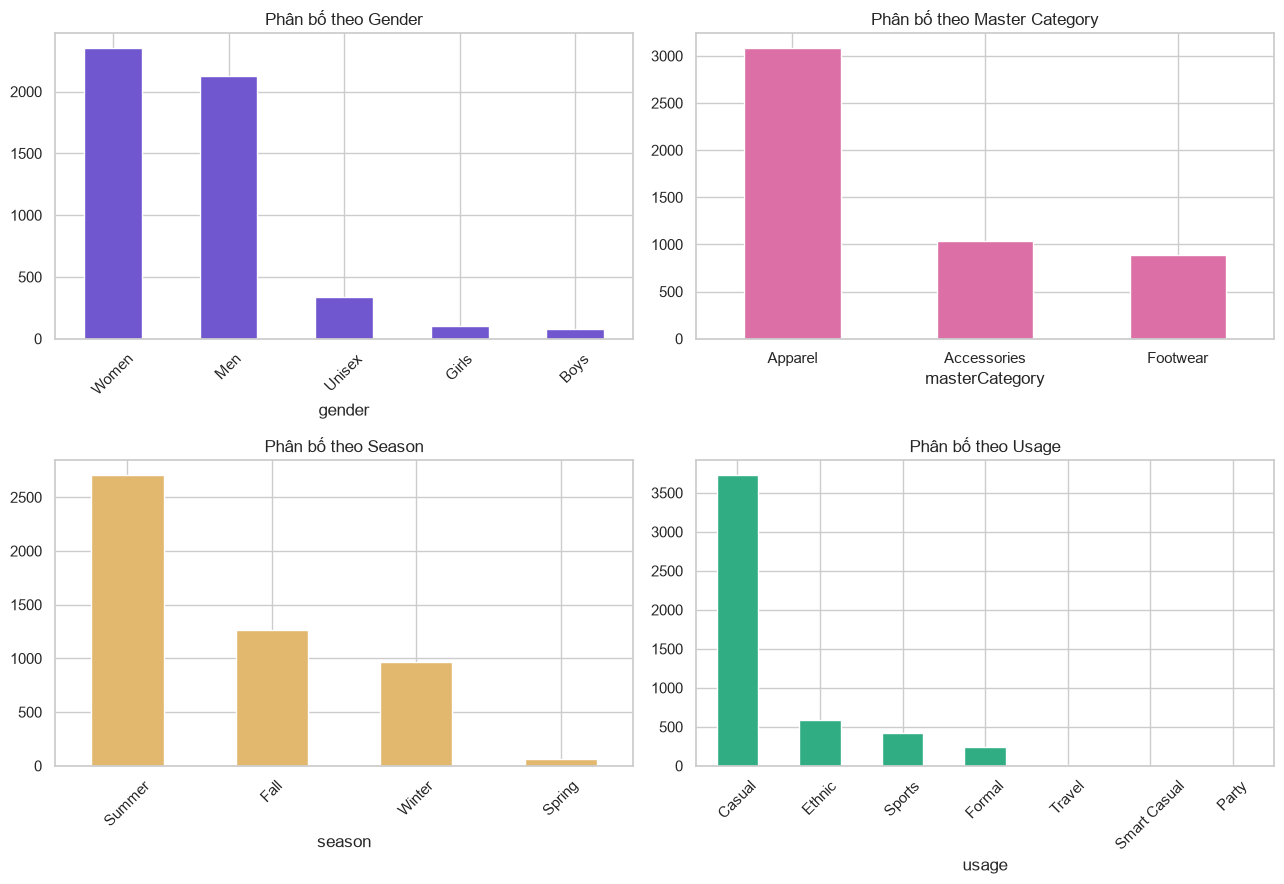

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

df['gender'].value_counts().plot(kind='bar', ax=axes[0,0], color="#7056cf")
axes[0,0].set_title('Phân bố theo Gender')
axes[0,0].tick_params(axis='x', rotation=45)

df['masterCategory'].value_counts().plot(kind='bar', ax=axes[0,1], color="#dc6fa6")
axes[0,1].set_title('Phân bố theo Master Category')
axes[0,1].tick_params(axis='x', rotation=0)

df['season'].value_counts().plot(kind='bar', ax=axes[1,0], color="#e2b86f")
axes[1,0].set_title('Phân bố theo Season')
axes[1,0].tick_params(axis='x', rotation=45)

df['usage'].value_counts().plot(kind='bar', ax=axes[1,1], color="#31ad84")
axes[1,1].set_title('Phân bố theo Usage')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

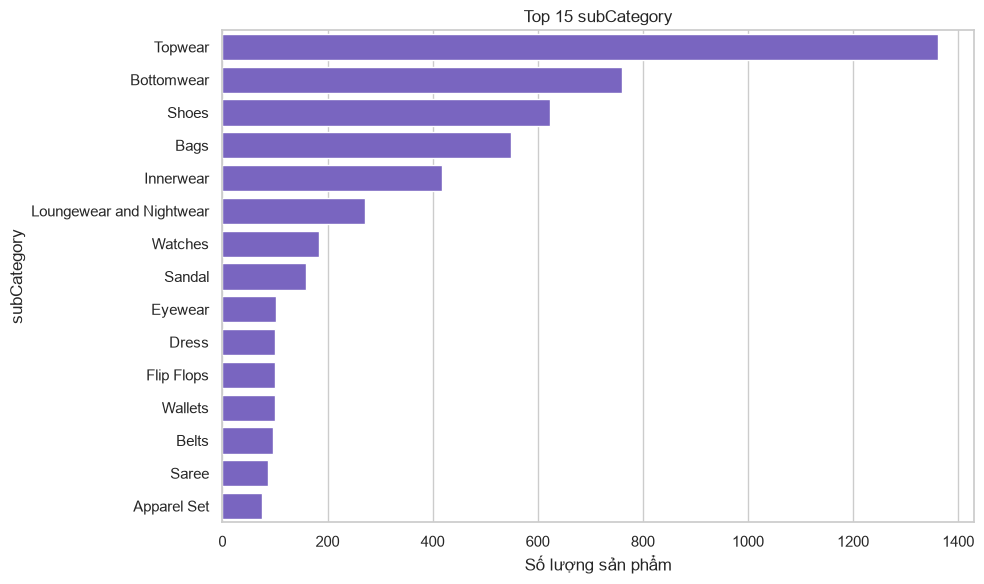

In [9]:
top_sub = df['subCategory'].value_counts().head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_sub.values, y=top_sub.index, color="#7056cf")
plt.title('Top 15 subCategory')
plt.xlabel('Số lượng sản phẩm')
plt.tight_layout()
plt.show()

In [10]:
vc = df['articleType'].value_counts()
print(f"Số articleType duy nhất: {vc.shape[0]}")
print(f"articleType có <=2 sản phẩm (long tail, dễ rơi vào product_not_found):")
vc[vc <= 2]

Số articleType duy nhất: 80
articleType có <=2 sản phẩm (long tail, dễ rơi vào product_not_found):


articleType
Travel Accessory    1
Suits               1
Name: count, dtype: int64

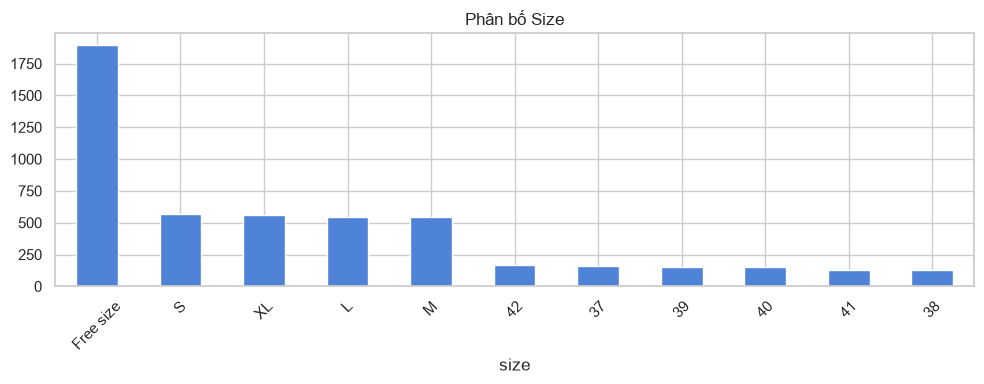

In [11]:
df['size'].value_counts().plot(kind='bar', figsize=(10,4), color="#4f83d7")
plt.title('Phân bố Size')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **4. Phân bố các biến numeric**

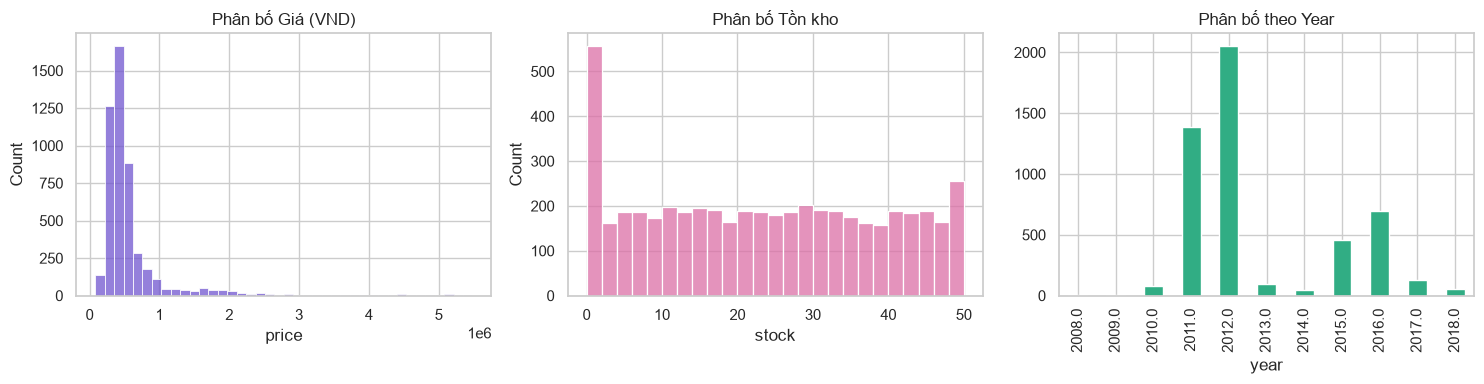

,price,stock,year
count,5.000000e+03,5000.000000,5000.000000
mean,6.177886e+05,22.930800,2012.750400
std,6.667965e+05,15.453963,1.979819
min,8.100000e+04,0.000000,2008.000000
25%,3.380000e+05,9.000000,2011.000000
50%,4.370000e+05,23.000000,2012.000000
75%,5.480000e+05,36.000000,2015.000000
max,5.483000e+06,50.000000,2018.000000


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['price'], bins=40, ax=axes[0], color='#7056cf')
axes[0].set_title('Phân bố Giá (VND)')

sns.histplot(df['stock'], bins=25, ax=axes[1], color='#dc6fa6')
axes[1].set_title('Phân bố Tồn kho')

df['year'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='#31ad84')
axes[2].set_title('Phân bố theo Year')

plt.tight_layout()
plt.show()
df[['price','stock','year']].describe()

In [13]:
stock_zero = (df['stock'] == 0).sum()
print(f"Sản phẩm hết hàng (stock=0): {stock_zero}/{len(df)} ({stock_zero/len(df):.1%})")
df[df['stock']==0]['masterCategory'].value_counts()

Sản phẩm hết hàng (stock=0): 473/5000 (9.5%)


masterCategory
Apparel        302
Accessories     97
Footwear        74
Name: count, dtype: int64

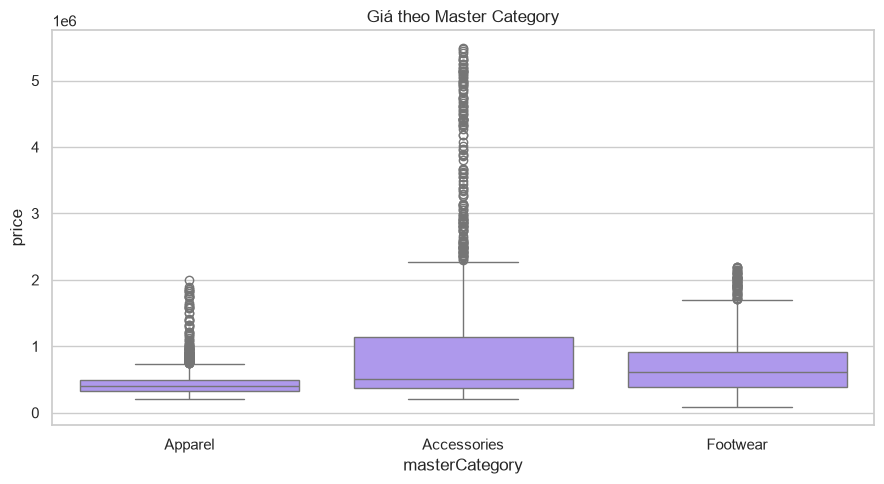

,mean,min,max
masterCategory,,,
Accessories,1.079980e+06,209000.0,5483000.0
Apparel,4.326178e+05,200000.0,1996000.0
Footwear,7.245504e+05,81000.0,2197000.0


In [14]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='masterCategory', y='price', color='#a78bfa')
plt.title('Giá theo Master Category')
plt.tight_layout()
plt.show()
df.groupby('masterCategory')['price'].describe()[['mean','min','max']]

## **5. Độ dài mô tả (liên quan chunk size khi embedding)**

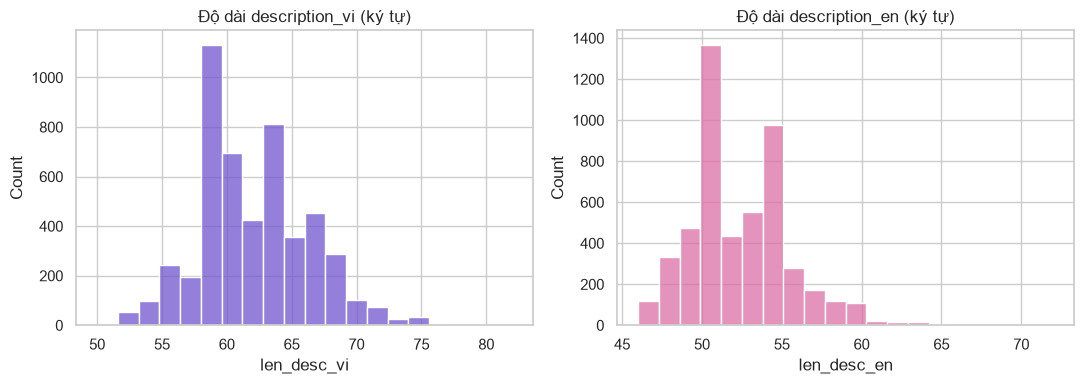

,len_desc_vi,len_desc_en
count,5000.000000,5000.000000
mean,61.945600,52.328000
std,4.265522,3.123775
min,50.000000,46.000000
25%,59.000000,50.000000
50%,62.000000,52.000000
75%,65.000000,55.000000
max,82.000000,72.000000


In [15]:
df['len_desc_vi'] = df['description_vi'].str.len()
df['len_desc_en'] = df['description_en'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.histplot(df['len_desc_vi'], bins=20, ax=axes[0], color='#7056cf')
axes[0].set_title('Độ dài description_vi (ký tự)')
sns.histplot(df['len_desc_en'], bins=20, ax=axes[1], color='#dc6fa6')
axes[1].set_title('Độ dài description_en (ký tự)')
plt.tight_layout()
plt.show()

df[['len_desc_vi','len_desc_en']].describe()

**Nhận xét:** mô tả rất ngắn (45-80 ký tự) và theo template cố định (không phải văn tự do) — an toàn cho chunk size, nhưng cũng đồng nghĩa các sản phẩm cùng loại/màu có embedding rất gần nhau về mặt mô tả, chỉ khác nhờ dòng giá/tồn kho/mã sản phẩm.

## **6. Kết luận & khuyến nghị**

1. Thêm `Mã sản phẩm: SP{id}` vào nội dung chunk (`build_index.py`) — nếu không, model không có cách trích dẫn/phân biệt khi 2 SKU trùng tên + màu + size cùng lọt vào context.
2. Thêm rule vào system prompt: khi CONTEXT có nhiều SKU trùng tên/màu/size nhưng khác mã, phải liệt kê riêng từng mã kèm giá/tồn kho, không gộp/chọn đại 1 cái.
3. Cân nhắc thêm cột `sku_note` hoặc field riêng trong `products.csv` để đánh dấu các nhóm SKU trùng tên + màu + size ngay từ bước clean, giúp debug nhanh hơn về sau.